<a href="https://colab.research.google.com/github/tanishqsayil-lab/MLEL--Experiment/blob/main/Assign9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.head(10))
print("Rows and Columns:", X.shape)
print("Target Names:", data.target_names)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   
5        12.45         15.70           82.57      477.1          0.12780   
6        18.25         19.98          119.60     1040.0          0.09463   
7        13.71         20.83           90.20      577.9          0.11890   
8        13.00         21.82           87.50      519.8          0.12730   
9        12.46         24.04           83.97      475.9          0.11860   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760         0.30010              0.14710         0.2419   
1           0

In [3]:
print(X.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (455, 30)
Test Shape: (114, 30)


In [5]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

pred1 = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, pred1))
print("Tree Depth:", dt.get_depth())
print("Number of Nodes:", dt.tree_.node_count)

Decision Tree Accuracy: 0.9473684210526315
Tree Depth: 7
Number of Nodes: 31


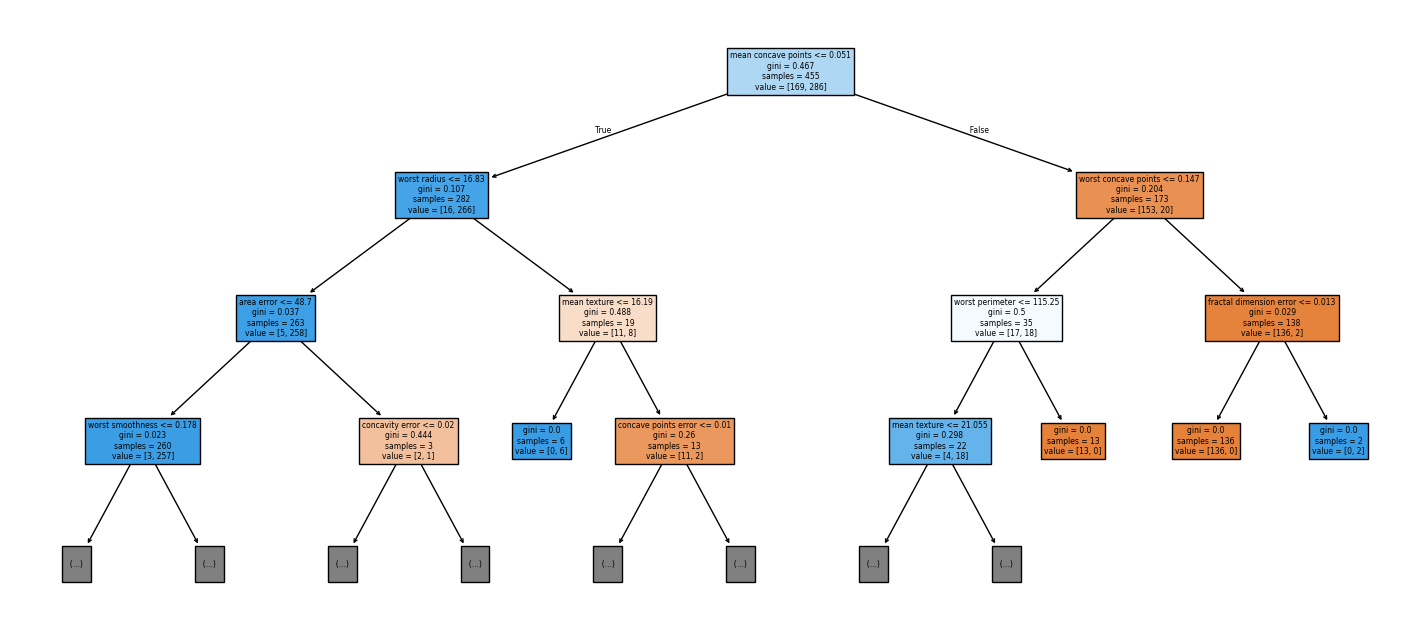

In [6]:
plt.figure(figsize=(18,8))
plot_tree(dt, filled=True, max_depth=3, feature_names=X.columns)
plt.show()

In [7]:
dt2 = DecisionTreeClassifier(max_depth=3, random_state=42)
dt2.fit(X_train, y_train)

pred2 = dt2.predict(X_test)

print("Pruned Tree Accuracy:", accuracy_score(y_test, pred2))
print("Depth:", dt2.get_depth())

Pruned Tree Accuracy: 0.9473684210526315
Depth: 3


In [8]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

pred3 = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, pred3))

Random Forest Accuracy: 0.9649122807017544


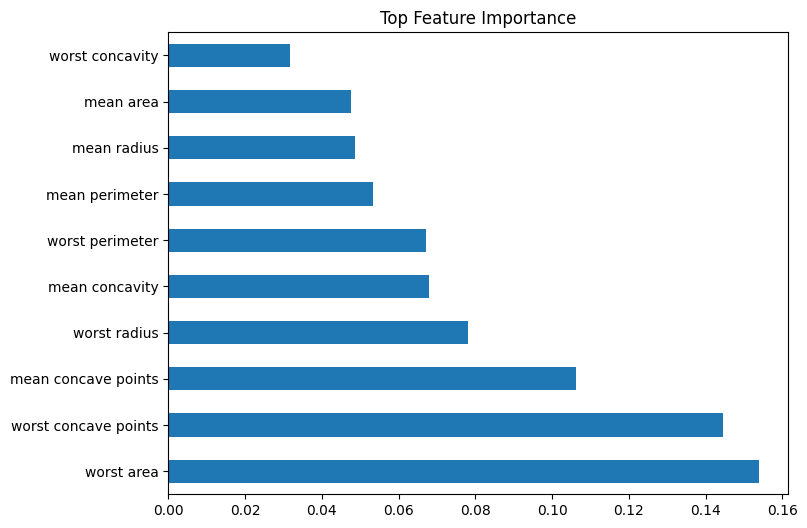

In [9]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh', figsize=(8,6))
plt.title("Top Feature Importance")
plt.show()

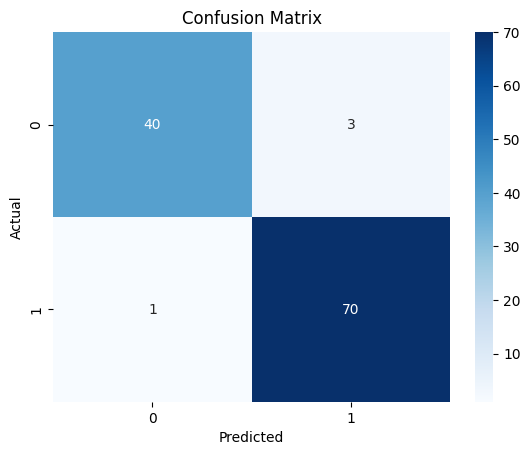

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Random Forest reduces overfitting by using many trees.
Decision Tree is useful when easy interpretation is needed.


In [10]:
cm = confusion_matrix(y_test, pred3)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, pred3))

print("Random Forest reduces overfitting by using many trees.")
print("Decision Tree is useful when easy interpretation is needed.")